# Examples: Data Processing

This is a trivial example of how to create data for CNSistent, fill missing segments, impute missing values, create consistent segmentation, aggregate the values and plot the results.

In [2]:
%load_ext autoreload
%autoreload 2

import io
import pandas as pd
import matplotlib.pyplot as plt

# Import the cns module
import cns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Create data

A two SCNA profiles for samples s1, s2 with copy number columns CN1, CN2

In [3]:
cns_source = """sample_id, chrom, start, end, CN1, CN2
s1, chr19, 1000000, 3000000, 1,
s1, chr19, 3000000, 12000000, 1, 1
s1, chr19, 12000000, 14000000, , 1
s1, chr19, 14000000, 21000000, 3, 1
s1, chr19, 21000000, 25000000, 3, 
s1, chr19, 28000000, 58500000, 3,
s2, chr19, 1000000, 24000000, 2,
s2, chr19, 29000000, 58000000, 0,
"""
raw_cns_df = pd.read_csv(io.StringIO(cns_source.strip()), sep=',\s*', engine='python')
raw_cns_df.head()

,sample_id,chrom,start,end,CN1,CN2
0,s1,chr19,1000000,3000000,1.0,NaN
1,s1,chr19,3000000,12000000,1.0,1.0
2,s1,chr19,12000000,14000000,NaN,1.0
3,s1,chr19,14000000,21000000,3.0,1.0
4,s1,chr19,21000000,25000000,3.0,NaN


Heatmap of the above values, note that the positions are on the linear genome

(<Figure size 300x300 with 2 Axes>,
 array([<Axes: xlabel='CN1'>, <Axes: xlabel='CN2'>], dtype=object))

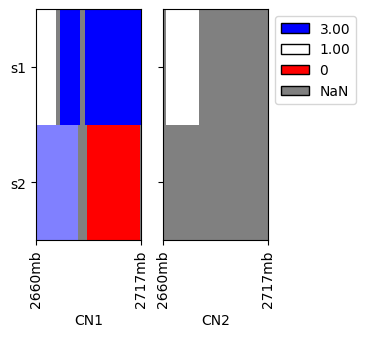

In [4]:
cns.fig_heatmap(raw_cns_df)

Prepare segments for masking limited to chr19

In [5]:
chr19_seg = cns.regions_select("chr19")
print(chr19_seg)

{'chr19': [(0, 59128983, 'chr19')]}


## Coverage and filling

Analyze the existing coverage

In [6]:
cover_df = cns.main_coverage(raw_cns_df, segs=chr19_seg)
cover_df.head()

,sex,chrom_count,chrom_missing,cover_het_aut,cover_het_sex,cover_het_all,cover_hom_aut,cover_hom_sex,cover_hom_all
sample_id,,,,,,,,,
s1,xx,1,[],0.921714,0,0.921714,0.270595,0,0.270595
s2,xx,1,[],0.879433,0,0.879433,0.000000,0,0.000000


Create missing segments with NaN values.

In [7]:
fill_cns_df = cns.main_fill(raw_cns_df, add_missing_chromosomes=False)
fill_cns_df.head()

,sample_id,chrom,start,end,CN1,CN2
0,s1,chr19,0,1000000,NaN,NaN
1,s1,chr19,1000000,3000000,1.0,NaN
2,s1,chr19,3000000,12000000,1.0,1.0
3,s1,chr19,12000000,14000000,NaN,1.0
4,s1,chr19,14000000,21000000,3.0,1.0


The data are now extended to the boundaries of chromosome 19

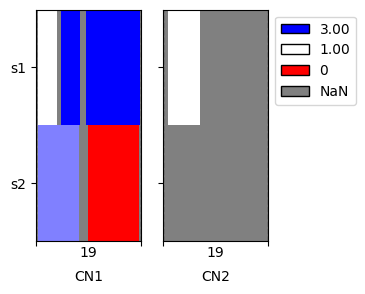

In [8]:
cns.fig_heatmap(fill_cns_df, cn_columns=['CN1', 'CN2']);

## Imputation and aneuploidy

Fill values into the missing segments. Leading and trailing NaN values are filled with the first and last non-NaN value, respectively. The remaining NaN values are filled with the mean of the non-NaN values.

In [9]:
imp_cns_df = cns.main_impute(fill_cns_df)
imp_cns_df.head()

,sample_id,chrom,start,end,CN1,CN2
0,s1,chr19,0,13000000,1,1
1,s1,chr19,13000000,59128983,3,1
2,s2,chr19,0,26500000,2,0
3,s2,chr19,26500000,59128983,0,0


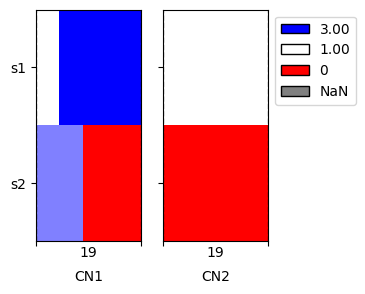

In [10]:
cns.fig_heatmap(imp_cns_df, cn_columns=['CN1', 'CN2']);

In [11]:
ploidy_df = cns.main_ploidy(imp_cns_df)
ploidy_df.head()

,sex,loh_hom_aut,loh_het_aut,ane_het_aut,ane_hom_aut,imb_CN1_aut,imb_CN2_aut,ploidy_CN1,ploidy_CN2
sample_id,,,,,,,,,
s1,xx,0.000000,0.000000,0.016011,0.000000,0.016011,0.0,2.560283,1.0
s2,xx,0.011325,0.020524,0.020524,0.020524,0.009198,0.0,0.896346,0.0


In [12]:
breakage_df = cns.main_breakage(imp_cns_df)
breakage_df.head()

,sex,breaks_CN1_aut,step_CN1_aut,breaks_CN2_aut,step_CN2_aut
sample_id,,,,,
s1,xx,1,2.0,0,0
s2,xx,1,2.0,0,0


## Segment and aggregate

Get gap regions to remove from the genome:

In [13]:
gap_segs = cns.regions_select("gaps")
gap_segs["chr19"]

[(0, 10000, 'telomere'),
 (10000, 60000, 'contig'),
 (7346004, 7396004, 'contig'),
 (8687198, 8737198, 'contig'),
 (20523415, 20573415, 'clone'),
 (24631782, 24681782, 'heterochromatin'),
 (24681782, 27681782, 'centromere'),
 (27681782, 27731782, 'heterochromatin'),
 (59118983, 59128983, 'telomere')]

Create segmentation frot the data. Filter gap regions by 100kb, remove the rest from the sampling, create 3 mb bins.

Note that the original breakpoint at 13 mb is preserved in the segmentation.

In [14]:
seg_bins = cns.main_segment(imp_cns_df, remove_segs=gap_segs, split_size=3*10**6, filter_size=10**5)
seg_bins["chr19"][:5]

[(0, 3250000, 'chr19_0_0'),
 (3250000, 6500000, 'chr19_0_1'),
 (6500000, 9750000, 'chr19_0_2'),
 (9750000, 13000000, 'chr19_0_3'),
 (13000000, 15907946, 'chr19_1_0')]

Apply the segmentation to the data and aggregate the values.

In [15]:
agg_cns_df = cns.main_aggregate(imp_cns_df, seg_bins)
agg_cns_df.head()

,sample_id,chrom,start,end,CN1,CN2,name
0,s1,chr19,0,3250000,1.0,1.0,chr19_0_0
1,s1,chr19,3250000,6500000,1.0,1.0,chr19_0_1
2,s1,chr19,6500000,9750000,1.0,1.0,chr19_0_2
3,s1,chr19,9750000,13000000,1.0,1.0,chr19_0_3
4,s1,chr19,13000000,15907946,3.0,1.0,chr19_1_0


Create bars for the segments

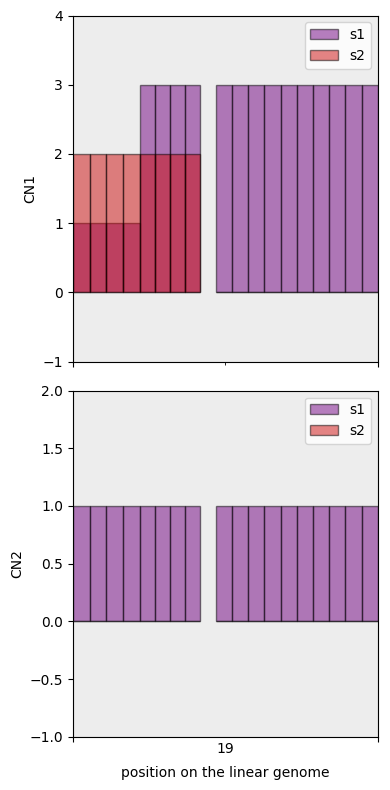

In [16]:
cns.fig_bars(agg_cns_df);

Sum the copy numbers and create a line plot for segments.

Note the interpolation between neighbours.

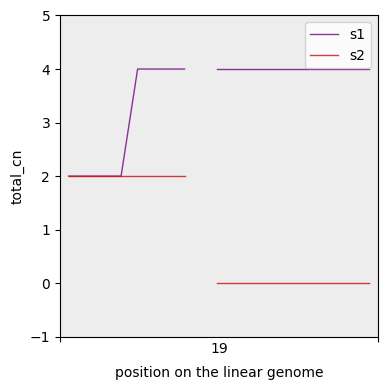

In [17]:
cns.fig_lines(cns.add_total_cn(agg_cns_df, inplace=False), cn_columns="total_cn");

## Conversions

In [30]:
features, samples, positions = cns.bins_to_features(agg_cns_df)
print(features.shape)
print(samples)
positions.head()

(2, 2, 18)
['s1', 's2']


,chrom,start,end
0,chr19,0,3250000
1,chr19,3250000,6500000
2,chr19,6500000,9750000
3,chr19,9750000,13000000
4,chr19,13000000,15907946


In [18]:
cns.cns_df_to_segments(agg_cns_df)["chr19"][:5]

[(0, 3250000, 'chr19_0_0'),
 (3250000, 6500000, 'chr19_0_1'),
 (6500000, 9750000, 'chr19_0_2'),
 (9750000, 13000000, 'chr19_0_3'),
 (13000000, 15907946, 'chr19_1_0')]

In [19]:
cns.segments_to_cns_df(gap_segs).head()

,chrom,start,end,name
0,chr1,0,10000,telomere
1,chr1,177417,227417,clone
2,chr1,267719,317719,contig
3,chr1,471368,521368,contig
4,chr1,2634220,2684220,clone


In [20]:
cns.segments_to_breaks(gap_segs)["chr19"][:5]

[0, 10000, 60000, 7346004, 7396004]

In [23]:
cns.breaks_to_segments({"chr19" : [0, 10000, 30000]})

{'chr19': [(0, 10000, 'chr19_0'), (10000, 30000, 'chr19_1')]}